In [1]:
!unzip -l /content/xd_violence/xd-violence-video-dataset.zip | head -50

unzip:  cannot find or open /content/xd_violence/xd-violence-video-dataset.zip, /content/xd_violence/xd-violence-video-dataset.zip.zip or /content/xd_violence/xd-violence-video-dataset.zip.ZIP.


In [3]:
import os, shutil

# Remove everything in /content except system folders
for item in os.listdir('/content'):
    if item not in ['sample_data']:
        try:
            shutil.rmtree(f'/content/{item}')
        except:
            os.remove(f'/content/{item}')

# Check free space
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   87G  20% /


In [4]:
!rm -rf /content/*
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   87G  20% /


In [5]:
import json, os

kaggle_username = "anapkrishna"  # ← change this
kaggle_key      = "KGAT_58018588de6aabf02ea9ccacefaabbe2"       # ← change this

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

!kaggle datasets download -d nguhaduong/xd-violence-video-dataset \
  --path /content/xd_violence

print('Downloaded!')

Dataset URL: https://www.kaggle.com/datasets/nguhaduong/xd-violence-video-dataset
License(s): apache-2.0
100% 62.8G/62.8G [1:06:24<00:00, 16.9MB/s]

Downloaded!


In [7]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/xd_violence/xd-violence-video-dataset.zip \
   /content/drive/MyDrive/xd_violence.zip

print('Saved to Drive!')

Mounted at /content/drive
^C
Saved to Drive!


In [8]:
!unzip /content/xd_violence/xd-violence-video-dataset.zip \
  -d /content/xd_violence/extracted

Archive:  /content/xd_violence/xd-violence-video-dataset.zip
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_0_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_100_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_101_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_102_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_103_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_104_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_105_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_106_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_107_Fighting.mp4  
  inflating: /content/xd_violence/extracted/XD_violence/test/Fighting/Test_108_Fighting.mp4  
 

In [9]:
import zipfile

# See what's inside without extracting
with zipfile.ZipFile('/content/xd_violence/xd-violence-video-dataset.zip') as z:
    files = z.namelist()
    print(f'Total files: {len(files)}')
    # Show folder structure
    folders = set('/'.join(f.split('/')[:2]) for f in files if '/' in f)
    for f in sorted(folders):
        print(f)

Total files: 3330
XD_violence/test
XD_violence/train


In [10]:
with zipfile.ZipFile('/content/xd_violence/xd-violence-video-dataset.zip') as z:
    files = z.namelist()

    # Get all unique subcategories
    folders = set('/'.join(f.split('/')[:3]) for f in files if len(f.split('/')) > 2)
    for f in sorted(folders):
        print(f)

XD_violence/test/Fighting
XD_violence/test/Normal
XD_violence/test/Shooting
XD_violence/train/Fighting
XD_violence/train/Normal
XD_violence/train/Shooting


In [11]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='darkgrid')

ZIP_PATH = '/content/xd_violence/xd-violence-video-dataset.zip'
VIOLENCE_CATS = ['Fighting', 'Shooting']
ALL_CATS = VIOLENCE_CATS + ['Normal']

# Count videos per category
with zipfile.ZipFile(ZIP_PATH) as z:
    files = z.namelist()

records = []
for split in ['train', 'test']:
    for cat in ALL_CATS:
        prefix = f'XD_violence/{split}/{cat}/'
        count = sum(1 for f in files if f.startswith(prefix) and f.endswith('.mp4'))
        records.append({'split': split.capitalize(), 'category': cat, 'count': count})

count_df = pd.DataFrame(records)
print(count_df.to_string(index=False))

split category  count
Train Fighting    445
Train Shooting    335
Train   Normal   2046
 Test Fighting    120
 Test Shooting     84
 Test   Normal    300


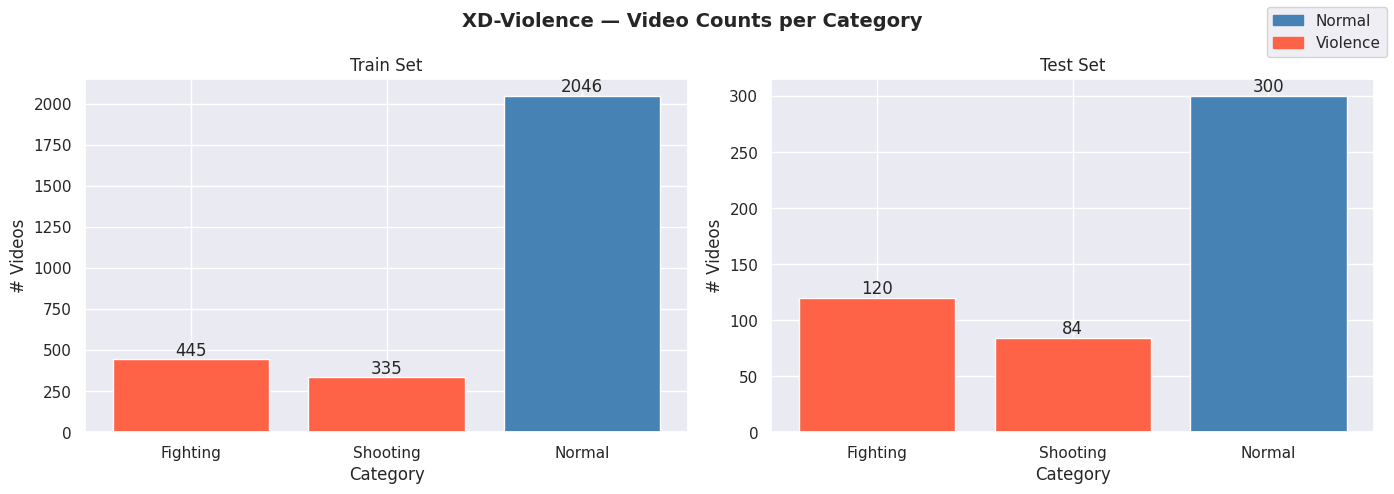

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XD-Violence — Video Counts per Category', fontsize=14, fontweight='bold')

for ax, split in zip(axes, ['Train', 'Test']):
    sub = count_df[count_df['split'] == split]
    bars = ax.bar(sub['category'], sub['count'],
                  color=['steelblue' if c == 'Normal' else 'tomato' for c in sub['category']],
                  edgecolor='white')
    ax.bar_label(bars)
    ax.set_title(f'{split} Set')
    ax.set_xlabel('Category')
    ax.set_ylabel('# Videos')

fig.legend(handles=[mpatches.Patch(color='steelblue', label='Normal'),
                    mpatches.Patch(color='tomato', label='Violence')], loc='upper right')
plt.tight_layout()
plt.show()

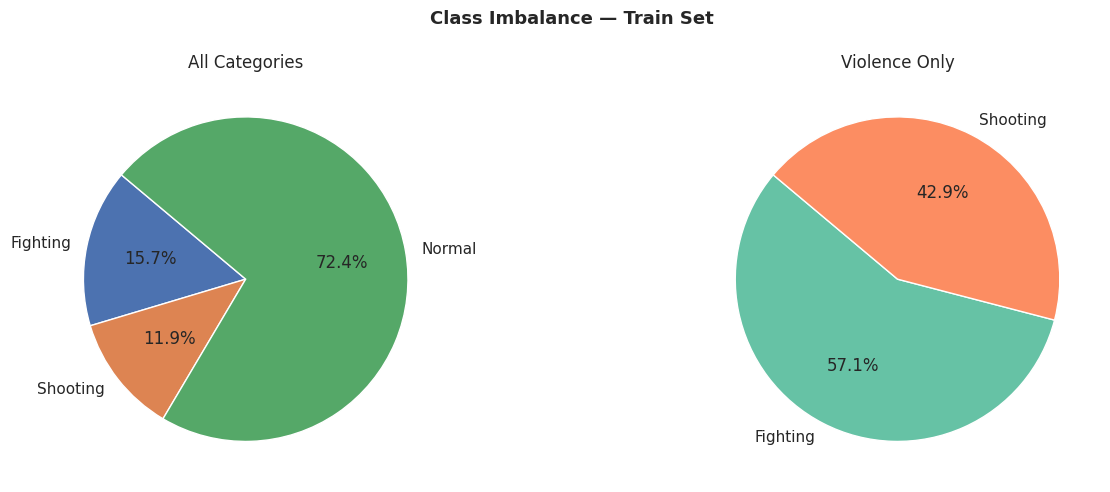

In [13]:
train_counts = count_df[count_df['split'] == 'Train'].set_index('category')['count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Imbalance — Train Set', fontsize=13, fontweight='bold')

axes[0].pie(train_counts.values, labels=train_counts.index,
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('All Categories')

viol = train_counts[VIOLENCE_CATS]
axes[1].pie(viol.values, labels=viol.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', 2))
axes[1].set_title('Violence Only')
plt.tight_layout()
plt.show()

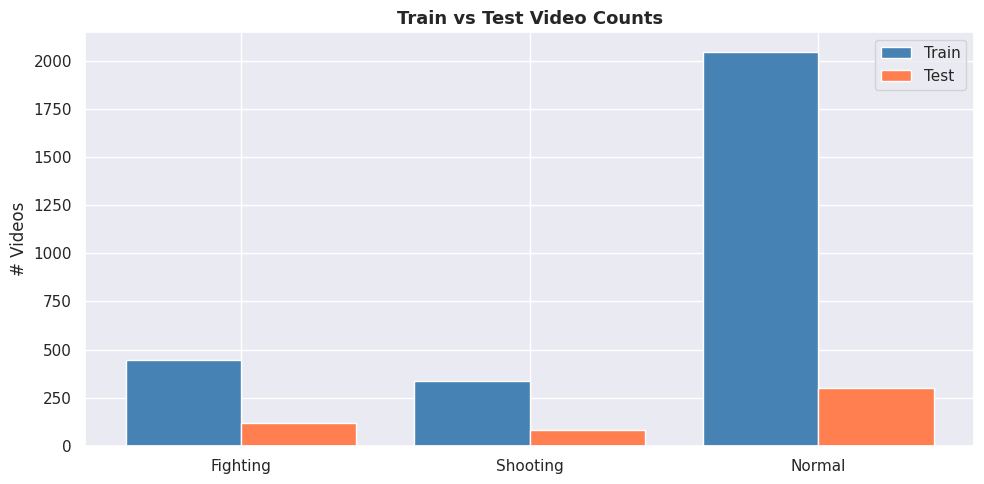

In [14]:
x = range(len(ALL_CATS))
train_vals = [count_df[(count_df['split']=='Train') & (count_df['category']==c)]['count'].values[0] for c in ALL_CATS]
test_vals  = [count_df[(count_df['split']=='Test')  & (count_df['category']==c)]['count'].values[0] for c in ALL_CATS]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - 0.2 for i in x], train_vals, width=0.4, label='Train', color='steelblue')
ax.bar([i + 0.2 for i in x], test_vals,  width=0.4, label='Test',  color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(ALL_CATS)
ax.set_title('Train vs Test Video Counts', fontsize=13, fontweight='bold')
ax.set_ylabel('# Videos')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
total_viol = train_counts[VIOLENCE_CATS].sum()
total_norm = train_counts['Normal']
print('='*45)
print('  XD-VIOLENCE SUBSET — SUMMARY')
print('='*45)
print(count_df.to_string(index=False))
print(f'\nImbalance ratio : 1:{total_norm/total_viol:.2f} (violence:normal)')
print('='*45)

  XD-VIOLENCE SUBSET — SUMMARY
split category  count
Train Fighting    445
Train Shooting    335
Train   Normal   2046
 Test Fighting    120
 Test Shooting     84
 Test   Normal    300

Imbalance ratio : 1:2.62 (violence:normal)


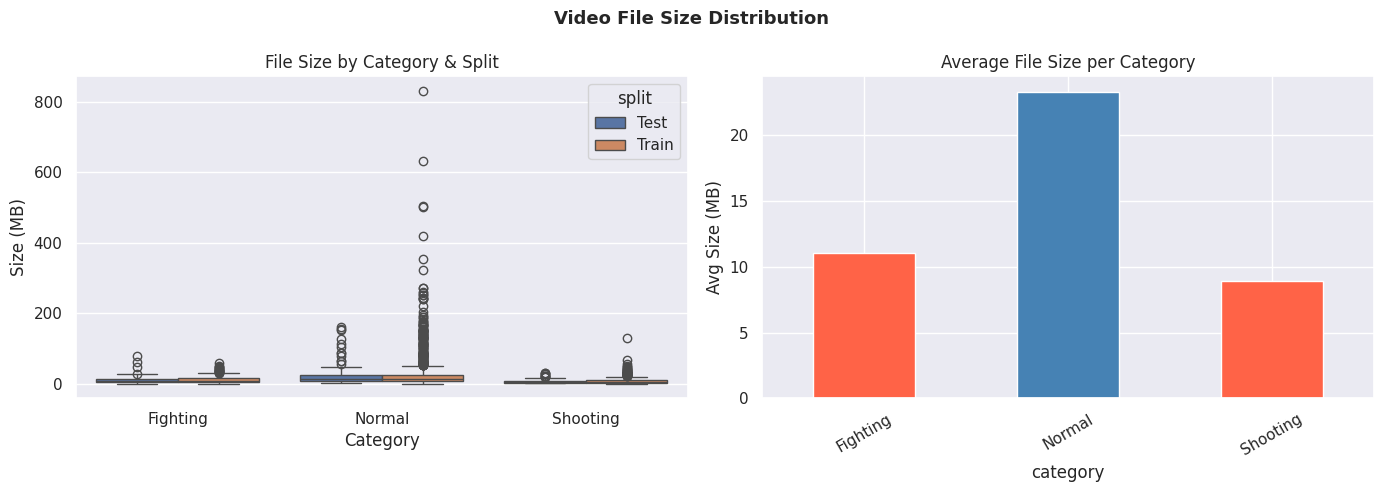

In [16]:
with zipfile.ZipFile(ZIP_PATH) as z:
    size_records = []
    for info in z.infolist():
        if info.filename.endswith('.mp4'):
            parts = info.filename.split('/')
            size_records.append({
                'split': parts[1].capitalize(),
                'category': parts[2],
                'filename': parts[3],
                'size_mb': info.file_size / (1024*1024)
            })

size_df = pd.DataFrame(size_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Video File Size Distribution', fontsize=13, fontweight='bold')

sns.boxplot(data=size_df, x='category', y='size_mb', hue='split', ax=axes[0])
axes[0].set_title('File Size by Category & Split')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Size (MB)')

size_df.groupby('category')['size_mb'].mean().plot(kind='bar', ax=axes[1],
    color=['tomato','steelblue','tomato'], edgecolor='white')
axes[1].set_title('Average File Size per Category')
axes[1].set_ylabel('Avg Size (MB)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

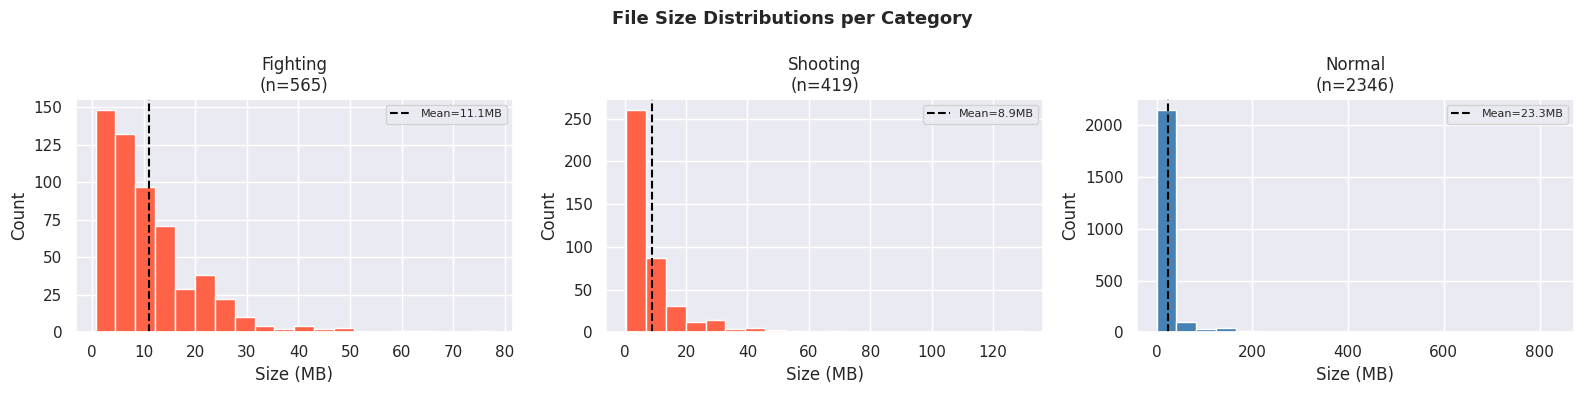

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('File Size Distributions per Category', fontsize=13, fontweight='bold')

for ax, cat in zip(axes, ALL_CATS):
    sub = size_df[size_df['category'] == cat]
    ax.hist(sub['size_mb'], bins=20,
            color='steelblue' if cat == 'Normal' else 'tomato',
            edgecolor='white')
    ax.set_title(f'{cat}\n(n={len(sub)})')
    ax.set_xlabel('Size (MB)')
    ax.set_ylabel('Count')
    ax.axvline(sub['size_mb'].mean(), color='black', linestyle='--',
               label=f'Mean={sub["size_mb"].mean():.1f}MB')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

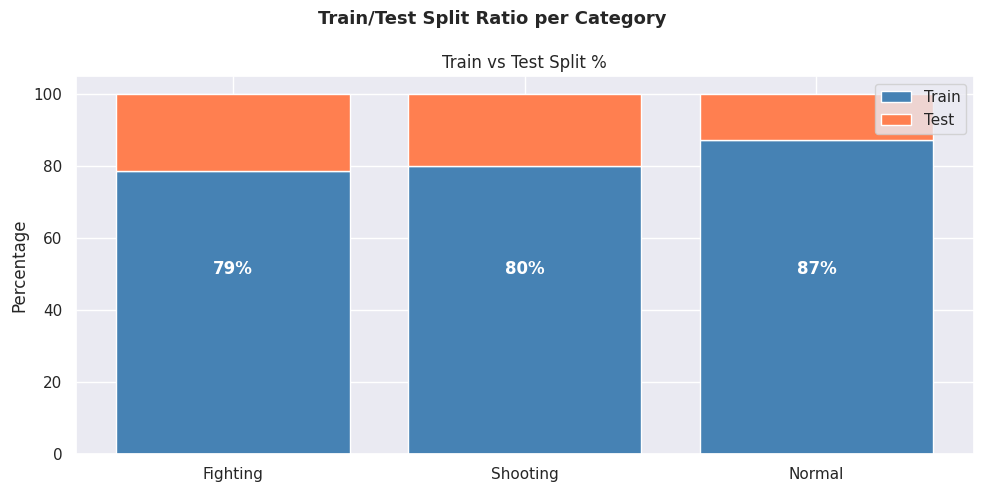

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Train/Test Split Ratio per Category', fontsize=13, fontweight='bold')

for i, cat in enumerate(ALL_CATS):
    train_n = count_df[(count_df['split']=='Train') & (count_df['category']==cat)]['count'].values[0]
    test_n  = count_df[(count_df['split']=='Test')  & (count_df['category']==cat)]['count'].values[0]
    total   = train_n + test_n
    ax.bar(i, train_n/total*100, color='steelblue', label='Train' if i==0 else '')
    ax.bar(i, test_n/total*100, bottom=train_n/total*100,
           color='coral', label='Test' if i==0 else '')
    ax.text(i, 50, f'{train_n/total*100:.0f}%', ha='center', color='white', fontweight='bold')

ax.set_xticks(range(len(ALL_CATS)))
ax.set_xticklabels(ALL_CATS)
ax.set_ylabel('Percentage')
ax.set_title('Train vs Test Split %')
ax.legend()
plt.tight_layout()
plt.show()